# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Upload and Data Cleaning

In [2]:
df = pd.read_csv("data/teams_match_features.csv", parse_dates=["_date"])
df.head()

,home_elo,away_elo,elo_diff,home_avg_overall,home_max_overall,home_avg_attack,home_avg_defense,home_avg_pace,home_avg_shooting,home_avg_passing,...,away_form_win_rate,is_neutral,is_world_cup,is_continental,home_goals,away_goals,_home_team,_away_team,_date,_tournament
0,1500.000000,1500.000000,0.000000,74.285714,76,74.50,74.250000,71.083333,69.500000,69.583333,...,0.330000,0,0,0,0,0,Scotland,England,1872-11-30,Friendly
1,1500.000000,1500.000000,0.000000,81.500000,86,82.25,81.222222,73.538462,69.923077,71.307692,...,0.000000,0,0,0,4,2,England,Scotland,1873-03-08,Friendly
2,1484.000000,1516.000000,-32.000000,74.285714,76,74.50,74.250000,71.083333,69.500000,69.583333,...,0.500000,0,0,0,2,1,Scotland,England,1874-03-07,Friendly
3,1498.530498,1501.469502,-2.939003,81.500000,86,82.25,81.222222,73.538462,69.923077,71.307692,...,0.333333,0,0,0,2,2,England,Scotland,1875-03-06,Friendly
4,1501.334159,1498.665841,2.668317,74.285714,76,74.50,74.250000,71.083333,69.500000,69.583333,...,0.250000,0,0,0,3,0,Scotland,England,1876-03-04,Friendly


In [3]:
# We order the dataframe by date to ensure that the data is in chronological order. 
# This is important for time series analysis and modeling, as it allows us to capture the temporal dependencies in the data.
df = df.sort_values("_date").reset_index(drop=True)

In [4]:
# Check for missing values in the dataset
print(df.isnull().sum())

home_elo                0
away_elo                0
elo_diff                0
home_avg_overall        0
home_max_overall        0
home_avg_attack         0
home_avg_defense        0
home_avg_pace         697
home_avg_shooting     697
home_avg_passing      697
away_avg_overall        0
away_max_overall        0
away_avg_attack         0
away_avg_defense        0
away_avg_pace         801
away_avg_shooting     801
away_avg_passing      801
overall_diff            0
attack_diff             0
defense_diff            0
home_form_scored        0
home_form_conceded      0
home_form_win_rate      0
away_form_scored        0
away_form_conceded      0
away_form_win_rate      0
is_neutral              0
is_world_cup            0
is_continental          0
home_goals              0
away_goals              0
_home_team              0
_away_team              0
_date                   0
_tournament             0
dtype: int64


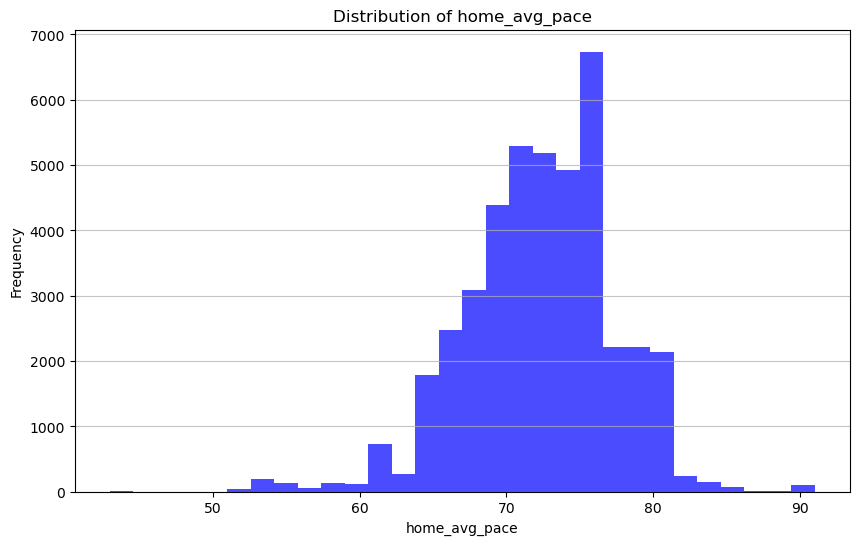

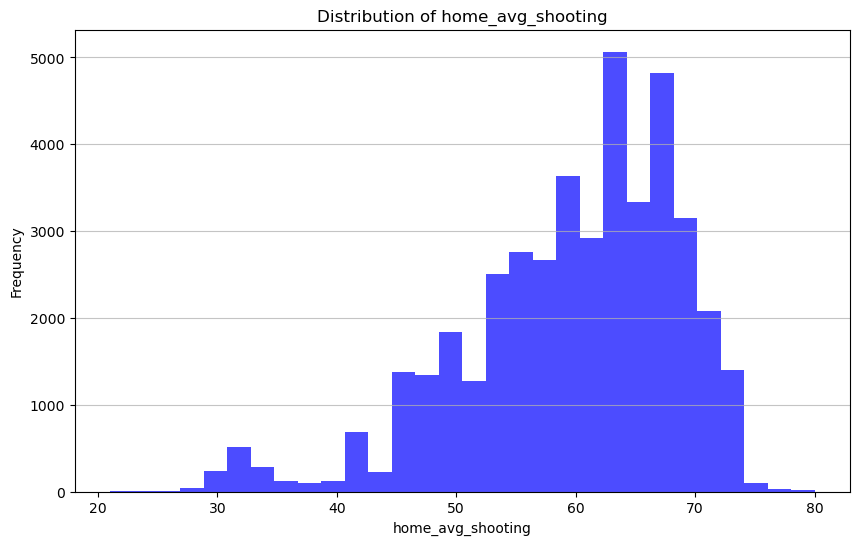

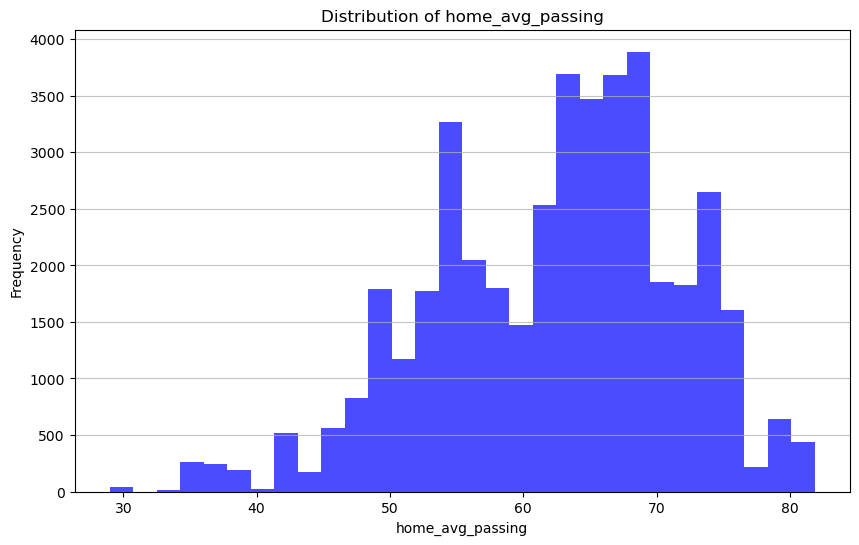

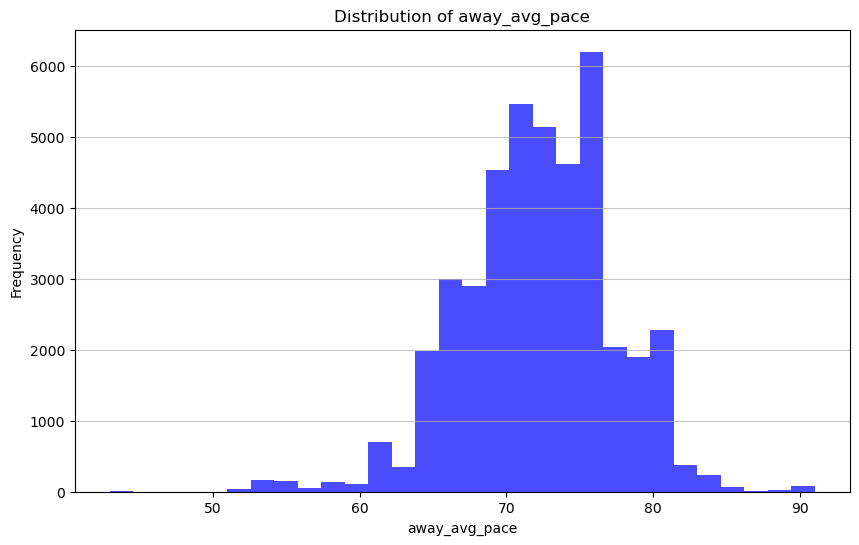

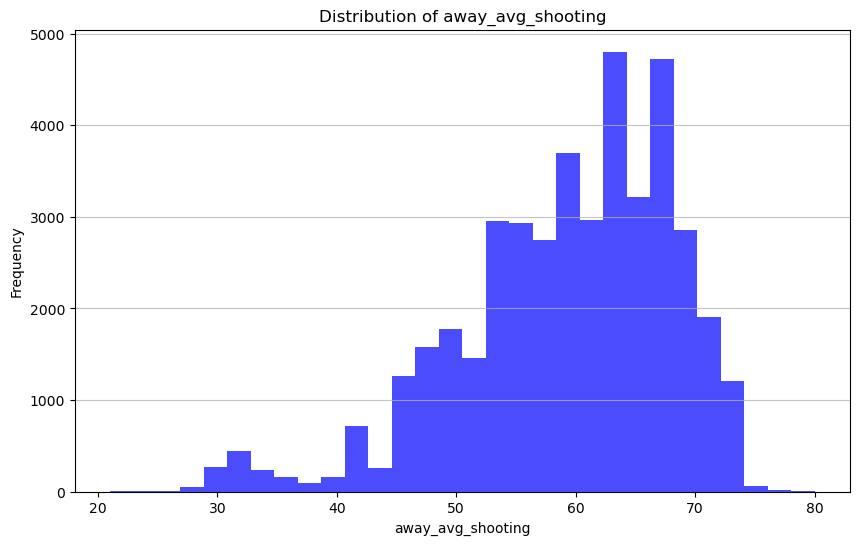

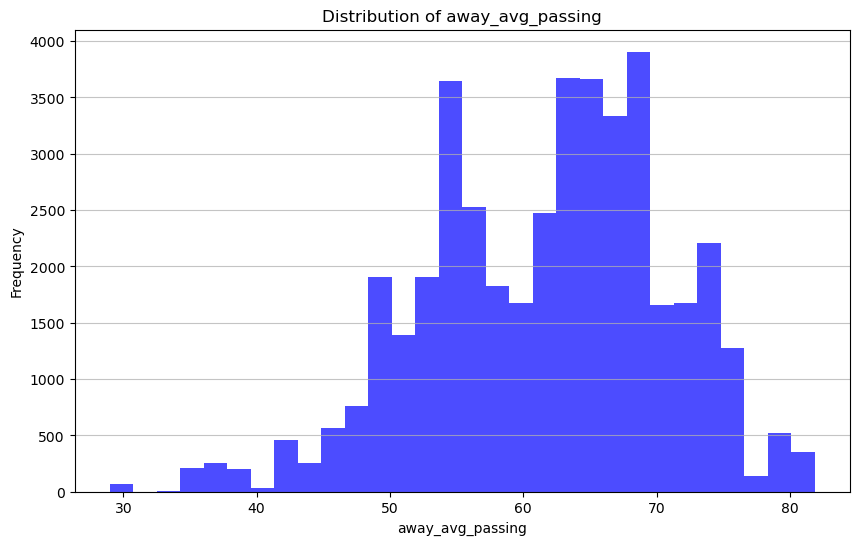

In [5]:
# Graphicaly we visualize the distribution of the characteristics wich have missing values, in order to decide how to handle them. 

cols_null = df.columns[df.isnull().any()].tolist()

for characteristic in cols_null:
    plt.figure(figsize=(10, 6))
    plt.hist(df[characteristic].dropna(), bins=30, alpha=0.7, color='blue')
    plt.title(f'Distribution of {characteristic}')
    plt.xlabel(characteristic)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

As observed, the distributions exhibit a significant degree of skewness and some outliers. Consequently, the mean does not constitute a representative statistic for imputing missing values in this context. Therefore, the median will be employed as the imputation measure, as it is more robust to skewed distributions and is expected to yield more reliable and accurate results.

In [6]:
# We fill the missing values with the median of each characteristic, as it is a robust measure of central tendency that is less affected by outliers than the mean.

for col in cols_null:
    df[col] = df[col].fillna(df[col].median())

print(df.shape)
print(df.isnull().sum().sum(), "Remaining missing values")

(43364, 35)
0 Remaining missing values


## Feature Engineering

**Define the Target Variable**

In [7]:
# We create a new column "result" to represent the outcome of each match. The values are encoded as follows: 
# 0 for a home win, 1 for a draw, and 2 for an away win. This will be useful for training our predictive model.

def get_result(row):
    if row["home_goals"] > row["away_goals"]:
        return 0  # local wins
    elif row["home_goals"] == row["away_goals"]:
        return 1  # draw
    else:
        return 2  # visitor wins

df["result"] = df.apply(get_result, axis=1)
print(df["result"].value_counts(normalize=True))

result
0    0.564777
1    0.234619
2    0.200604
Name: proportion, dtype: float64


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43364 entries, 0 to 43363
Data columns (total 36 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   home_elo            43364 non-null  float64       
 1   away_elo            43364 non-null  float64       
 2   elo_diff            43364 non-null  float64       
 3   home_avg_overall    43364 non-null  float64       
 4   home_max_overall    43364 non-null  int64         
 5   home_avg_attack     43364 non-null  float64       
 6   home_avg_defense    43364 non-null  float64       
 7   home_avg_pace       43364 non-null  float64       
 8   home_avg_shooting   43364 non-null  float64       
 9   home_avg_passing    43364 non-null  float64       
 10  away_avg_overall    43364 non-null  float64       
 11  away_max_overall    43364 non-null  int64         
 12  away_avg_attack     43364 non-null  float64       
 13  away_avg_defense    43364 non-null  float64       
 14  a

As shown above, several features in the dataset are represented as string or date-time variables. Given that these features are not relevant to the predictive task under consideration, they will be omitted from the analysis and model development process.

In [9]:
feature_cols = [
    "home_elo", "away_elo", "elo_diff",
    "home_avg_overall", "away_avg_overall", "overall_diff",
    "home_avg_attack", "away_avg_attack", "attack_diff",
    "home_avg_defense", "away_avg_defense", "defense_diff",
    "home_form_scored", "home_form_conceded", "home_form_win_rate",
    "away_form_scored", "away_form_conceded", "away_form_win_rate",
    "is_neutral", "is_world_cup", "is_continental"
]

X = df[feature_cols]
y = df["result"]

## Train/Test Split considering Time

In time series analysis, we cannot randomly split the data using a standard train-test split. Doing so would allow the model to be trained on matches from 2020 and tested on matches from 1990, which would introduce data leakage and result in an unrealistic evaluation. In practice, future information is never available when making predictions about the past. Therefore, the dataset is split chronologically, the model is trained on historical data and evaluated using the most recent observations.


In [10]:
from sklearn.model_selection import train_test_split

# We use the oldest 85% of the data for training and the most recent 15% for testing
split_idx = int(len(df) * 0.85)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Traning:", X_train.shape, "to", df.iloc[split_idx-1]["_date"])
print("Test:", X_test.shape, "from", df.iloc[split_idx]["_date"])

Traning: (36859, 21) to 2017-11-11 00:00:00
Test: (6505, 21) from 2017-11-11 00:00:00


## Model Training

We´ll use a Random Forest model will be employed for this task, as it offers several advantages for predictive modeling:
- It effectively captures non-linear relationships within the data. For example, an Elo rating difference of 200 points does not necessarily have twice the impact of a difference of 100 points.
- It does not require feature scaling or data normalization, simplifying the preprocessing pipeline.
- It provides measures of feature importance, allowing for greater model interpretability and a better understanding of the factors that drive predictions.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    class_weight="balanced"  # Helps address class imbalance, as draws represent a minority class.
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Gana local", "Empate", "Gana visitante"]))

Accuracy: 0.6098385857033052
                precision    recall  f1-score   support

    Gana local       0.76      0.70      0.73      3689
        Empate       0.35      0.32      0.34      1569
Gana visitante       0.52      0.69      0.60      1247

      accuracy                           0.61      6505
     macro avg       0.54      0.57      0.55      6505
  weighted avg       0.62      0.61      0.61      6505



In [12]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)

elo_diff              0.257996
is_neutral            0.202521
overall_diff          0.098258
attack_diff           0.062758
away_elo              0.062475
defense_diff          0.061932
home_elo              0.056816
away_avg_attack       0.028571
away_avg_overall      0.027390
home_form_conceded    0.023407
away_avg_defense      0.020212
away_form_conceded    0.018859
home_avg_overall      0.016305
home_avg_attack       0.015933
home_avg_defense      0.015072
away_form_scored      0.010121
home_form_scored      0.008791
away_form_win_rate    0.006462
home_form_win_rate    0.006001
is_continental        0.000121
is_world_cup          0.000000
dtype: float64


## Build the Spain - Argentina Match

In [13]:
# 1. Most recent Elo rating and form of each team
def get_latest_team_stats(df, team):
    # Find the most recent match played by the team, whether as the home or away side.
    home_rows = df[df["_home_team"] == team][["_date", "home_elo", "home_avg_overall",
                    "home_avg_attack", "home_avg_defense",
                    "home_form_scored", "home_form_conceded", "home_form_win_rate"]]
    home_rows.columns = ["_date", "elo", "avg_overall", "avg_attack", "avg_defense",
                          "form_scored", "form_conceded", "form_win_rate"]

    away_rows = df[df["_away_team"] == team][["_date", "away_elo", "away_avg_overall",
                    "away_avg_attack", "away_avg_defense",
                    "away_form_scored", "away_form_conceded", "away_form_win_rate"]]
    away_rows.columns = ["_date", "elo", "avg_overall", "avg_attack", "avg_defense",
                          "form_scored", "form_conceded", "form_win_rate"]

    all_rows = pd.concat([home_rows, away_rows]).sort_values("_date")
    return all_rows.iloc[-1]  # The most recent record

spain_stats = get_latest_team_stats(df, "Spain")
argentina_stats = get_latest_team_stats(df, "Argentina")

print("España, último dato:", spain_stats["_date"])
print("Argentina, último dato:", argentina_stats["_date"])

España, último dato: 2025-11-18 00:00:00
Argentina, último dato: 2025-11-14 00:00:00


We now construct the feature vector for the hypothetical match (2026 World Cup = neutral venue in the United States, Mexico, or Canada).

In [14]:
match_features = pd.DataFrame([{
    "home_elo": spain_stats["elo"],
    "away_elo": argentina_stats["elo"],
    "elo_diff": spain_stats["elo"] - argentina_stats["elo"],
    "home_avg_overall": spain_stats["avg_overall"],
    "away_avg_overall": argentina_stats["avg_overall"],
    "overall_diff": spain_stats["avg_overall"] - argentina_stats["avg_overall"],
    "home_avg_attack": spain_stats["avg_attack"],
    "away_avg_attack": argentina_stats["avg_attack"],
    "attack_diff": spain_stats["avg_attack"] - argentina_stats["avg_attack"],
    "home_avg_defense": spain_stats["avg_defense"],
    "away_avg_defense": argentina_stats["avg_defense"],
    "defense_diff": spain_stats["avg_defense"] - argentina_stats["avg_defense"],
    "home_form_scored": spain_stats["form_scored"],
    "home_form_conceded": spain_stats["form_conceded"],
    "home_form_win_rate": spain_stats["form_win_rate"],
    "away_form_scored": argentina_stats["form_scored"],
    "away_form_conceded": argentina_stats["form_conceded"],
    "away_form_win_rate": argentina_stats["form_win_rate"],
    "is_neutral": 1,     # Mundial en sede neutral
    "is_world_cup": 1,
    "is_continental": 0
}])[feature_cols]

proba = model.predict_proba(match_features)[0]
print(f"Prob. gana España:     {proba[0]:.1%}")
print(f"Prob. empate:          {proba[1]:.1%}")
print(f"Prob. gana Argentina:  {proba[2]:.1%}")

Prob. gana España:     52.2%
Prob. empate:          41.8%
Prob. gana Argentina:  6.1%


In [15]:
match_features_swapped = pd.DataFrame([{
    "home_elo": argentina_stats["elo"],
    "away_elo": spain_stats["elo"],
    "elo_diff": argentina_stats["elo"] - spain_stats["elo"],
    "home_avg_overall": argentina_stats["avg_overall"],
    "away_avg_overall": spain_stats["avg_overall"],
    "overall_diff": argentina_stats["avg_overall"] - spain_stats["avg_overall"],
    "home_avg_attack": argentina_stats["avg_attack"],
    "away_avg_attack": spain_stats["avg_attack"],
    "attack_diff": argentina_stats["avg_attack"] - spain_stats["avg_attack"],
    "home_avg_defense": argentina_stats["avg_defense"],
    "away_avg_defense": spain_stats["avg_defense"],
    "defense_diff": argentina_stats["avg_defense"] - spain_stats["avg_defense"],
    "home_form_scored": argentina_stats["form_scored"],
    "home_form_conceded": argentina_stats["form_conceded"],
    "home_form_win_rate": argentina_stats["form_win_rate"],
    "away_form_scored": spain_stats["form_scored"],
    "away_form_conceded": spain_stats["form_conceded"],
    "away_form_win_rate": spain_stats["form_win_rate"],
    "is_neutral": 1,
    "is_world_cup": 1,
    "is_continental": 0
}])[feature_cols]

proba_swapped = model.predict_proba(match_features_swapped)[0]
print(f"Prob. gana Argentina:  {proba_swapped[0]:.1%}")
print(f"Prob. empate:          {proba_swapped[1]:.1%}")
print(f"Prob. gana España:     {proba_swapped[2]:.1%}")

Prob. gana Argentina:  49.3%
Prob. empate:          45.0%
Prob. gana España:     5.8%


In [16]:
def build_symmetric_dataset(df):
    base_cols = ["elo", "avg_overall", "avg_attack", "avg_defense"]
    form_cols_home = ["home_form_scored", "home_form_conceded", "home_form_win_rate"]
    form_cols_away = ["away_form_scored", "away_form_conceded", "away_form_win_rate"]
    context_cols = ["is_neutral", "is_world_cup", "is_continental"]

    # --- Fila A: team1 = home, team2 = away (igual al original) ---
    df_a = pd.DataFrame({
        "team1_elo": df["home_elo"], "team2_elo": df["away_elo"],
        "team1_overall": df["home_avg_overall"], "team2_overall": df["away_avg_overall"],
        "team1_attack": df["home_avg_attack"], "team2_attack": df["away_avg_attack"],
        "team1_defense": df["home_avg_defense"], "team2_defense": df["away_avg_defense"],
        "team1_form_scored": df["home_form_scored"], "team2_form_scored": df["away_form_scored"],
        "team1_form_conceded": df["home_form_conceded"], "team2_form_conceded": df["away_form_conceded"],
        "team1_form_win_rate": df["home_form_win_rate"], "team2_form_win_rate": df["away_form_win_rate"],
        "is_neutral": df["is_neutral"], "is_world_cup": df["is_world_cup"], "is_continental": df["is_continental"],
        "target": df["result"],  # 0=gana team1, 1=empate, 2=gana team2 (sin cambios)
        "_date": df["_date"]
    })

    # --- Fila B: team1 = away, team2 = home (invertido) ---
    df_b = pd.DataFrame({
        "team1_elo": df["away_elo"], "team2_elo": df["home_elo"],
        "team1_overall": df["away_avg_overall"], "team2_overall": df["home_avg_overall"],
        "team1_attack": df["away_avg_attack"], "team2_attack": df["home_avg_attack"],
        "team1_defense": df["away_avg_defense"], "team2_defense": df["home_avg_defense"],
        "team1_form_scored": df["away_form_scored"], "team2_form_scored": df["home_form_scored"],
        "team1_form_conceded": df["away_form_conceded"], "team2_form_conceded": df["home_form_conceded"],
        "team1_form_win_rate": df["away_form_win_rate"], "team2_form_win_rate": df["home_form_win_rate"],
        "is_neutral": df["is_neutral"], "is_world_cup": df["is_world_cup"], "is_continental": df["is_continental"],
        "target": df["result"].map({0: 2, 1: 1, 2: 0}),  # invertimos: gana local -> ahora es team2
        "_date": df["_date"]
    })

    # Features derivadas de diferencia (más importantes para el modelo)
    result = pd.concat([df_a, df_b], ignore_index=True)
    result["elo_diff"] = result["team1_elo"] - result["team2_elo"]
    result["overall_diff"] = result["team1_overall"] - result["team2_overall"]
    result["attack_diff"] = result["team1_attack"] - result["team2_attack"]
    result["defense_diff"] = result["team1_defense"] - result["team2_defense"]

    return result.sort_values("_date").reset_index(drop=True)

df_sym = build_symmetric_dataset(df)
print(df_sym.shape)  # el doble de filas que antes

(86728, 23)


In [17]:
feature_cols_sym = [
    "team1_elo", "team2_elo", "elo_diff",
    "team1_overall", "team2_overall", "overall_diff",
    "team1_attack", "team2_attack", "attack_diff",
    "team1_defense", "team2_defense", "defense_diff",
    "team1_form_scored", "team1_form_conceded", "team1_form_win_rate",
    "team2_form_scored", "team2_form_conceded", "team2_form_win_rate",
    "is_neutral", "is_world_cup", "is_continental"
]

# Mismo split temporal 85/15 que antes
split_idx = int(len(df_sym) * 0.85)
X_train2 = df_sym.iloc[:split_idx][feature_cols_sym]
y_train2 = df_sym.iloc[:split_idx]["target"]
X_test2 = df_sym.iloc[split_idx:][feature_cols_sym]
y_test2 = df_sym.iloc[split_idx:]["target"]

model2 = RandomForestClassifier(
    n_estimators=300, max_depth=8, min_samples_leaf=20,
    random_state=42, class_weight="balanced"
)
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)
print("Accuracy:", accuracy_score(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2, target_names=["Gana team1", "Empate", "Gana team2"]))

Accuracy: 0.5607993850883936
              precision    recall  f1-score   support

  Gana team1       0.64      0.64      0.64      4938
      Empate       0.31      0.31      0.31      3135
  Gana team2       0.64      0.64      0.64      4937

    accuracy                           0.56     13010
   macro avg       0.53      0.53      0.53     13010
weighted avg       0.56      0.56      0.56     13010



In [18]:
match_v2 = pd.DataFrame([{
    "team1_elo": spain_stats["elo"], "team2_elo": argentina_stats["elo"],
    "elo_diff": spain_stats["elo"] - argentina_stats["elo"],
    "team1_overall": spain_stats["avg_overall"], "team2_overall": argentina_stats["avg_overall"],
    "overall_diff": spain_stats["avg_overall"] - argentina_stats["avg_overall"],
    "team1_attack": spain_stats["avg_attack"], "team2_attack": argentina_stats["avg_attack"],
    "attack_diff": spain_stats["avg_attack"] - argentina_stats["avg_attack"],
    "team1_defense": spain_stats["avg_defense"], "team2_defense": argentina_stats["avg_defense"],
    "defense_diff": spain_stats["avg_defense"] - argentina_stats["avg_defense"],
    "team1_form_scored": spain_stats["form_scored"], "team1_form_conceded": spain_stats["form_conceded"],
    "team1_form_win_rate": spain_stats["form_win_rate"],
    "team2_form_scored": argentina_stats["form_scored"], "team2_form_conceded": argentina_stats["form_conceded"],
    "team2_form_win_rate": argentina_stats["form_win_rate"],
    "is_neutral": 1, "is_world_cup": 1, "is_continental": 0
}])[feature_cols_sym]

proba2 = model2.predict_proba(match_v2)[0]
print(f"Prob. gana España:     {proba2[0]:.1%}")
print(f"Prob. empate:          {proba2[1]:.1%}")
print(f"Prob. gana Argentina:  {proba2[2]:.1%}")

Prob. gana España:     33.1%
Prob. empate:          39.3%
Prob. gana Argentina:  27.6%


In [19]:
match_v2_swapped = pd.DataFrame([{
    "team1_elo": argentina_stats["elo"], "team2_elo": spain_stats["elo"],
    "elo_diff": argentina_stats["elo"] - spain_stats["elo"],
    "team1_overall": argentina_stats["avg_overall"], "team2_overall": spain_stats["avg_overall"],
    "overall_diff": argentina_stats["avg_overall"] - spain_stats["avg_overall"],
    "team1_attack": argentina_stats["avg_attack"], "team2_attack": spain_stats["avg_attack"],
    "attack_diff": argentina_stats["avg_attack"] - spain_stats["avg_attack"],
    "team1_defense": argentina_stats["avg_defense"], "team2_defense": spain_stats["avg_defense"],
    "defense_diff": argentina_stats["avg_defense"] - spain_stats["avg_defense"],
    "team1_form_scored": argentina_stats["form_scored"], "team1_form_conceded": argentina_stats["form_conceded"],
    "team1_form_win_rate": argentina_stats["form_win_rate"],
    "team2_form_scored": spain_stats["form_scored"], "team2_form_conceded": spain_stats["form_conceded"],
    "team2_form_win_rate": spain_stats["form_win_rate"],
    "is_neutral": 1, "is_world_cup": 1, "is_continental": 0
}])[feature_cols_sym]

proba2_swapped = model2.predict_proba(match_v2_swapped)[0]
print(f"Prob. gana Argentina:  {proba2_swapped[0]:.1%}")
print(f"Prob. empate:          {proba2_swapped[1]:.1%}")
print(f"Prob. gana España:     {proba2_swapped[2]:.1%}")

Prob. gana Argentina:  27.6%
Prob. empate:          39.4%
Prob. gana España:     33.1%


# Goles

In [22]:
def build_symmetric_dataset(df):
    df_a = pd.DataFrame({
        "team1_elo": df["home_elo"], "team2_elo": df["away_elo"],
        "team1_overall": df["home_avg_overall"], "team2_overall": df["away_avg_overall"],
        "team1_attack": df["home_avg_attack"], "team2_attack": df["away_avg_attack"],
        "team1_defense": df["home_avg_defense"], "team2_defense": df["away_avg_defense"],
        "team1_form_scored": df["home_form_scored"], "team2_form_scored": df["away_form_scored"],
        "team1_form_conceded": df["home_form_conceded"], "team2_form_conceded": df["away_form_conceded"],
        "team1_form_win_rate": df["home_form_win_rate"], "team2_form_win_rate": df["away_form_win_rate"],
        "is_neutral": df["is_neutral"], "is_world_cup": df["is_world_cup"], "is_continental": df["is_continental"],
        "team1_goals": df["home_goals"], "team2_goals": df["away_goals"],
        "target": df["result"],
        "_date": df["_date"]
    })

    df_b = pd.DataFrame({
        "team1_elo": df["away_elo"], "team2_elo": df["home_elo"],
        "team1_overall": df["away_avg_overall"], "team2_overall": df["home_avg_overall"],
        "team1_attack": df["away_avg_attack"], "team2_attack": df["home_avg_attack"],
        "team1_defense": df["away_avg_defense"], "team2_defense": df["home_avg_defense"],
        "team1_form_scored": df["away_form_scored"], "team2_form_scored": df["home_form_scored"],
        "team1_form_conceded": df["away_form_conceded"], "team2_form_conceded": df["home_form_conceded"],
        "team1_form_win_rate": df["away_form_win_rate"], "team2_form_win_rate": df["home_form_win_rate"],
        "is_neutral": df["is_neutral"], "is_world_cup": df["is_world_cup"], "is_continental": df["is_continental"],
        "team1_goals": df["away_goals"], "team2_goals": df["home_goals"],
        "target": df["result"].map({0: 2, 1: 1, 2: 0}),
        "_date": df["_date"]
    })

    result = pd.concat([df_a, df_b], ignore_index=True)
    result["elo_diff"] = result["team1_elo"] - result["team2_elo"]
    result["overall_diff"] = result["team1_overall"] - result["team2_overall"]
    result["attack_diff"] = result["team1_attack"] - result["team2_attack"]
    result["defense_diff"] = result["team1_defense"] - result["team2_defense"]

    return result.sort_values("_date").reset_index(drop=True)

In [23]:
df_sym = build_symmetric_dataset(df)
print(df_sym.columns.tolist())
print(df_sym[["team1_goals", "team2_goals"]].head())

['team1_elo', 'team2_elo', 'team1_overall', 'team2_overall', 'team1_attack', 'team2_attack', 'team1_defense', 'team2_defense', 'team1_form_scored', 'team2_form_scored', 'team1_form_conceded', 'team2_form_conceded', 'team1_form_win_rate', 'team2_form_win_rate', 'is_neutral', 'is_world_cup', 'is_continental', 'team1_goals', 'team2_goals', 'target', '_date', 'elo_diff', 'overall_diff', 'attack_diff', 'defense_diff']
   team1_goals  team2_goals
0            0            0
1            0            0
2            4            2
3            2            4
4            2            1


In [24]:
from sklearn.linear_model import PoissonRegressor

X_train_g = df_sym.iloc[:split_idx][feature_cols_sym]
X_test_g = df_sym.iloc[split_idx:][feature_cols_sym]

y_train_g1 = df_sym.iloc[:split_idx]["team1_goals"]
y_train_g2 = df_sym.iloc[:split_idx]["team2_goals"]
y_test_g1 = df_sym.iloc[split_idx:]["team1_goals"]
y_test_g2 = df_sym.iloc[split_idx:]["team2_goals"]

model_goals1 = PoissonRegressor(alpha=1.0, max_iter=500)
model_goals2 = PoissonRegressor(alpha=1.0, max_iter=500)

model_goals1.fit(X_train_g, y_train_g1)
model_goals2.fit(X_train_g, y_train_g2)

from sklearn.metrics import mean_poisson_deviance
print("Deviance goles team1:", mean_poisson_deviance(y_test_g1, model_goals1.predict(X_test_g)))
print("Deviance goles team2:", mean_poisson_deviance(y_test_g2, model_goals2.predict(X_test_g)))

Deviance goles team1: 1.5135036205033607
Deviance goles team2: 1.513422419661443


In [25]:
lambda_espana = model_goals1.predict(match_v2)[0]
lambda_argentina = model_goals2.predict(match_v2)[0]

print(f"Goles esperados España:    {lambda_espana:.2f}")
print(f"Goles esperados Argentina: {lambda_argentina:.2f}")

Goles esperados España:    1.44
Goles esperados Argentina: 1.44


In [26]:
from scipy.stats import poisson
import numpy as np

max_goles = 6
matriz = np.zeros((max_goles+1, max_goles+1))
for i in range(max_goles+1):       # goles España
    for j in range(max_goles+1):   # goles Argentina
        matriz[i, j] = poisson.pmf(i, lambda_espana) * poisson.pmf(j, lambda_argentina)

# Los 5 marcadores más probables
import itertools
scores = [((i, j), matriz[i, j]) for i, j in itertools.product(range(max_goles+1), repeat=2)]
scores.sort(key=lambda x: -x[1])

print("Marcadores más probables:")
for (i, j), p in scores[:5]:
    print(f"  España {i} - {j} Argentina: {p:.1%}")

# Probabilidades agregadas (deben coincidir aprox. con el modelo de clasificación)
prob_gana_espana = np.tril(matriz, -1).sum()   # España > Argentina
prob_empate = np.trace(matriz)
prob_gana_argentina = np.triu(matriz, 1).sum() # Argentina > España

print(f"\nGana España: {prob_gana_espana:.1%}, Empate: {prob_empate:.1%}, Gana Argentina: {prob_gana_argentina:.1%}")

Marcadores más probables:
  España 1 - 1 Argentina: 11.6%
  España 1 - 2 Argentina: 8.4%
  España 2 - 1 Argentina: 8.4%
  España 0 - 1 Argentina: 8.1%
  España 1 - 0 Argentina: 8.1%

Gana España: 37.5%, Empate: 24.9%, Gana Argentina: 37.5%
